# **Loading Preprocessed Dataset**

The dataset used in this notebook was generated from the group preprocessing and EDA notebook.
This notebook focuses only on:
1. k-Nearest Neighbours (kNN)
2. Logistic Regression
for model training, hyperparameter tuning, performance evaluation, and model comparison

In [23]:
# Mounting to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# Defining and loading the Datasets
import pandas as pd
train_path = "/content/drive/MyDrive/COMM074_Project/preprocessed/train_preprocessed.csv"
test_path = "/content/drive/MyDrive/COMM074_Project/preprocessed/test_preprocessed.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.head()
train_df.info()

print(train_df.shape)
print(test_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 69 columns):
 #   Column                                                                           Non-Null Count  Dtype  
---  ------                                                                           --------------  -----  
 0   admission_grade                                                                  3539 non-null   float64
 1   previous_qualification_grade                                                     3539 non-null   float64
 2   age_at_enrollment                                                                3539 non-null   float64
 3   tuition_fees_up_to_date_Yes                                                      3539 non-null   float64
 4   unemployment_rate                                                                3539 non-null   float64
 5   gdp                                                                              3539 non-null   float64
 6   scholars

In [25]:
# Separate Features and Target
X_train = train_df.drop("target", axis=1)
y_train = train_df["target"]

X_test = test_df.drop("target", axis=1)
y_test = test_df["target"]

print(train_df.columns)

Index(['admission_grade', 'previous_qualification_grade', 'age_at_enrollment',
       'tuition_fees_up_to_date_Yes', 'unemployment_rate', 'gdp',
       'scholarship_holder_Yes', 'application_order', 'gender_Male',
       'debtor_Yes', 'displaced_Yes', 'course_Nursing',
       'application_mode_1st phase-general contingent', 'mothers_occupation_9',
       'fathers_occupation_9',
       'mothers_qualification_Secondary Education—12th Year of Schooling or Eq.',
       'fathers_qualification_Basic education 1st cycle (4th/5th year) or equiv.',
       'mothers_qualification_Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',
       'fathers_qualification_Secondary Education—12th Year of Schooling or Eq.',
       'application_mode_Over 23 years old', 'mothers_occupation_4',
       'fathers_qualification_Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',
       'fathers_occupation_7', 'course_Informatics Engineering',
       'mothers_qualification_Basic education 1st cycle (4th/5

# **K-Nearest Neighbors (kNN)**

In [26]:
import pandas as pd
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Baseline kNN Classification Report
              precision    recall  f1-score   support

           0       0.52      0.45      0.48       284
           1       0.27      0.21      0.24       159
           2       0.62      0.72      0.67       442

    accuracy                           0.54       885
   macro avg       0.47      0.46      0.46       885
weighted avg       0.52      0.54      0.53       885

Baseline kNN Evaluation Metrics
Base_kNN Macro F1-Score: 0.4628
Base_kNN Weighted F1-Score: 0.5307
Base_kNN Balanced Accuracy: 0.4618
Base_kNN Accuracy: 0.5424


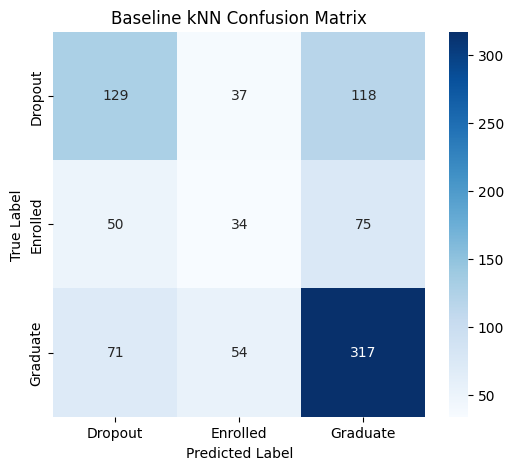

In [28]:
# Training Baseline kNN Model and Evaluation

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print("Baseline kNN Classification Report")

print(classification_report(y_test, y_pred_knn))

# Evaluation Metrics
baseline_kNN_macro_f1 = f1_score(y_test, y_pred_knn, average='macro')
baseline_kNN_weighted_f1 = f1_score(y_test, y_pred_knn, average='weighted')
baseline_kNN_balanced_acc = balanced_accuracy_score(y_test, y_pred_knn)
baseline_kNN_accuracy = accuracy_score(y_test, y_pred_knn)

print("Baseline kNN Evaluation Metrics")

print("Base_kNN Macro F1-Score:", round(baseline_kNN_macro_f1, 4))
print("Base_kNN Weighted F1-Score:", round(baseline_kNN_weighted_f1, 4))
print("Base_kNN Balanced Accuracy:", round(baseline_kNN_balanced_acc, 4))
print("Base_kNN Accuracy:", round(baseline_kNN_accuracy, 4))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_knn)
display_labels=['Dropout','Enrolled','Graduate']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels= display_labels,
    yticklabels= display_labels
)

plt.title("Baseline kNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [29]:
# Hyperparameter Tuning
print("Hyperparameter Tuning")

param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance']
}

# Stratified Cross Validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_weighted'
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:",
      round(grid_search.best_score_,4))

# Best model after tuning
best_knn = grid_search.best_estimator_

# Predictions using tuned model
y_pred_best_knn = best_knn.predict(X_test_scaled)

Hyperparameter Tuning
Best Parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Best Cross Validation Score: 0.5551


Tuned kNN Classification Report
              precision    recall  f1-score   support

           0       0.56      0.41      0.47       284
           1       0.31      0.23      0.26       159
           2       0.62      0.78      0.69       442

    accuracy                           0.56       885
   macro avg       0.50      0.47      0.47       885
weighted avg       0.54      0.56      0.54       885

Tuned kNN Evaluation Metrics
Tuned_kNN Macro F1-Score: 0.4745
Tuned_kNN Weighted F1-Score: 0.5429
Tuned_kNN Balanced Accuracy: 0.4726
Tuned_kNN Accuracy: 0.5627


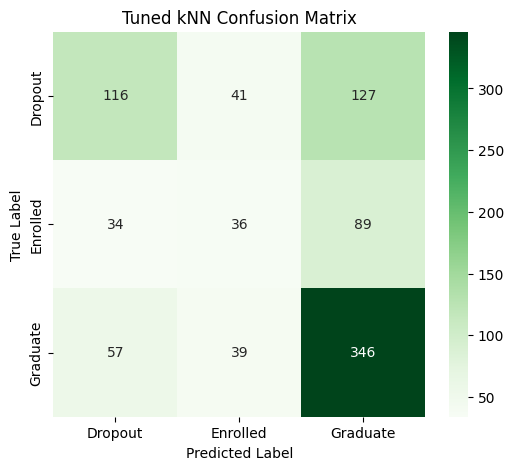

In [30]:
# Evaluation of Tuned Model
print("Tuned kNN Classification Report")

print(classification_report(y_test, y_pred_best_knn))

# Evaluation Metrics
tuned_kNN_macro_f1 = f1_score(y_test, y_pred_best_knn, average='macro')
tuned_kNN_weighted_f1 = f1_score(y_test, y_pred_best_knn, average='weighted')
tuned_kNN_balanced_acc = balanced_accuracy_score(y_test, y_pred_best_knn)
tuned_kNN_accuracy = accuracy_score(y_test, y_pred_best_knn)

print("Tuned kNN Evaluation Metrics")

print("Tuned_kNN Macro F1-Score:", round(tuned_kNN_macro_f1, 4))
print("Tuned_kNN Weighted F1-Score:", round(tuned_kNN_weighted_f1, 4))
print("Tuned_kNN Balanced Accuracy:", round(tuned_kNN_balanced_acc, 4))
print("Tuned_kNN Accuracy:", round(tuned_kNN_accuracy, 4))

# Tuned Confusion Matrix

cm = confusion_matrix(y_test, y_pred_best_knn)
display_labels=['Dropout','Enrolled','Graduate']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels= display_labels,
    yticklabels= display_labels
)

plt.title("Tuned kNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

Model Comparison
          Model  Macro F1  Weighted F1  Balanced Accuracy  Accuracy
0  Baseline kNN    0.4628       0.5307             0.4618    0.5424
1     Tuned kNN    0.4745       0.5429             0.4726    0.5627


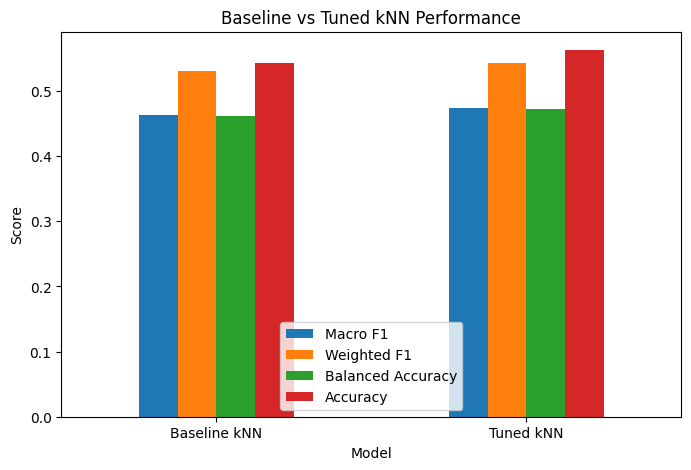

In [31]:
import matplotlib.pyplot as plt

# Compare Baseline vs Tuned

comparison_df = pd.DataFrame({

    'Model': ['Baseline kNN','Tuned kNN'],

    'Macro F1': [baseline_kNN_macro_f1,tuned_kNN_macro_f1],
    'Weighted F1': [baseline_kNN_weighted_f1,tuned_kNN_weighted_f1],
    'Balanced Accuracy': [baseline_kNN_balanced_acc,tuned_kNN_balanced_acc],
    'Accuracy': [baseline_kNN_accuracy,tuned_kNN_accuracy]
})

print("Model Comparison")

print(comparison_df.round(4))

# Graphical Comparison

comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Baseline vs Tuned kNN Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

# **Logistic Regression**


In [32]:
# Logistic Regression
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

import seaborn as sns
import matplotlib.pyplot as plt

logreg_model = LogisticRegression(C=10, solver='lbfgs', max_iter=2500, random_state=42)
logreg_model.fit(X_train_scaled, y_train)
y_pred_logreg = logreg_model.predict(X_test_scaled)

Baseline LogReg Classification Report
              precision    recall  f1-score   support

           0       0.65      0.58      0.61       284
           1       0.30      0.14      0.20       159
           2       0.66      0.83      0.73       442

    accuracy                           0.62       885
   macro avg       0.54      0.52      0.51       885
weighted avg       0.59      0.62      0.60       885

Baseline LogReg Evaluation Metrics
Base_LR Macro F1-Score: 0.5133
Base_LR Weighted F1-Score: 0.5975
Base_LR Balanced Accuracy: 0.5167
Base_LR Accuracy: 0.6249


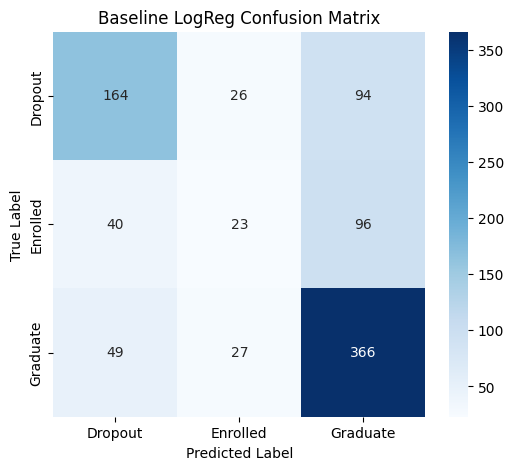

In [33]:
# LogReg Baseline Model Evaluation
print("Baseline LogReg Classification Report")

print(classification_report(y_test, y_pred_logreg))

# Evaluation Metrics
baseline_LR_macro_f1 = f1_score(y_test,y_pred_logreg,average='macro')
baseline_LR_weighted_f1 = f1_score(y_test,y_pred_logreg,average='weighted')
baseline_LR_balanced_acc = balanced_accuracy_score(y_test,y_pred_logreg)
baseline_LR_accuracy = accuracy_score(y_test,y_pred_logreg)

print("Baseline LogReg Evaluation Metrics")

print("Base_LR Macro F1-Score:", round(baseline_LR_macro_f1, 4))
print("Base_LR Weighted F1-Score:", round(baseline_LR_weighted_f1, 4))
print("Base_LR Balanced Accuracy:", round(baseline_LR_balanced_acc, 4))
print("Base_LR Accuracy:", round(baseline_LR_accuracy, 4))

# Baseline Confusion Matrix
cm = confusion_matrix(y_test, y_pred_logreg)
display_labels = ['Dropout', 'Enrolled', 'Graduate']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=display_labels,
    yticklabels=display_labels
)

plt.title("Baseline LogReg Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [34]:
# Hyperparameter Tuning

print("Hyperparameter Tuning")

param_grid = {
    'C': [0.01, 0.04, 0.05, 0.1, 0.3, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced', None],
    'max_iter': [3500],
    'multi_class': ['ovr']
}

# Stratified Cross Validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_weighted'
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:",
      round(grid_search.best_score_,4))

best_logreg = grid_search.best_estimator_

y_pred_best_logreg = best_logreg.predict(X_test_scaled)

Hyperparameter Tuning


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 3500, 'multi_class': 'ovr', 'solver': 'liblinear'}
Best Cross Validation Score: 0.6337


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Tuned LogReg Classification Report
              precision    recall  f1-score   support

           0       0.67      0.58      0.62       284
           1       0.32      0.36      0.34       159
           2       0.71      0.74      0.72       442

    accuracy                           0.62       885
   macro avg       0.57      0.56      0.56       885
weighted avg       0.63      0.62      0.62       885

Tuned LogReg Evaluation Metrics
Tuned_LR Macro F1-Score: 0.563
Tuned_LR Weighted F1-Score: 0.6225
Tuned_LR Balanced Accuracy: 0.5611
Tuned_LR Accuracy: 0.6203


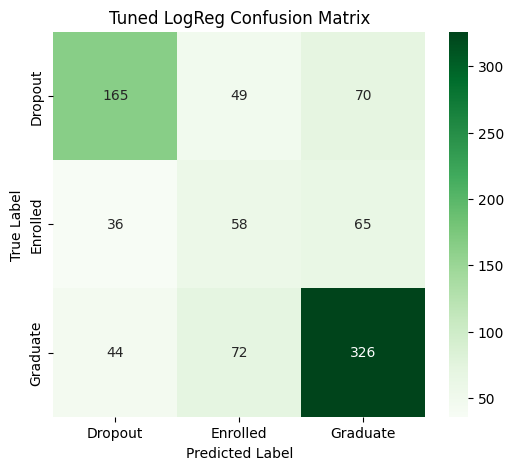

In [35]:
# Evaluation of Tuned Model

print("Tuned LogReg Classification Report")

print(classification_report(y_test, y_pred_best_logreg))

# Evaluation Metrics
tuned_LR_macro_f1 = f1_score(y_test,y_pred_best_logreg,average='macro')
tuned_LR_weighted_f1 = f1_score(y_test,y_pred_best_logreg,average='weighted')
tuned_LR_balanced_acc = balanced_accuracy_score(y_test,y_pred_best_logreg)
tuned_LR_accuracy = accuracy_score(y_test,y_pred_best_logreg)

print("Tuned LogReg Evaluation Metrics")

print("Tuned_LR Macro F1-Score:",round(tuned_LR_macro_f1, 4))
print("Tuned_LR Weighted F1-Score:",round(tuned_LR_weighted_f1, 4))
print("Tuned_LR Balanced Accuracy:",round(tuned_LR_balanced_acc, 4))
print("Tuned_LR Accuracy:",round(tuned_LR_accuracy, 4))


# Tuned LogReg Confusion Matrix

cm = confusion_matrix(y_test, y_pred_best_logreg)
display_labels = ['Dropout', 'Enrolled', 'Graduate']

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=display_labels,
    yticklabels=display_labels
)

plt.title("Tuned LogReg Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

Model Comparison
                          Model  Macro F1  Weighted F1  Balanced Accuracy  \
0  Baseline Logistic Regression    0.5133       0.5975             0.5167   
1     Tuned Logistic Regression    0.5630       0.6225             0.5611   

   Accuracy  
0    0.6249  
1    0.6203  


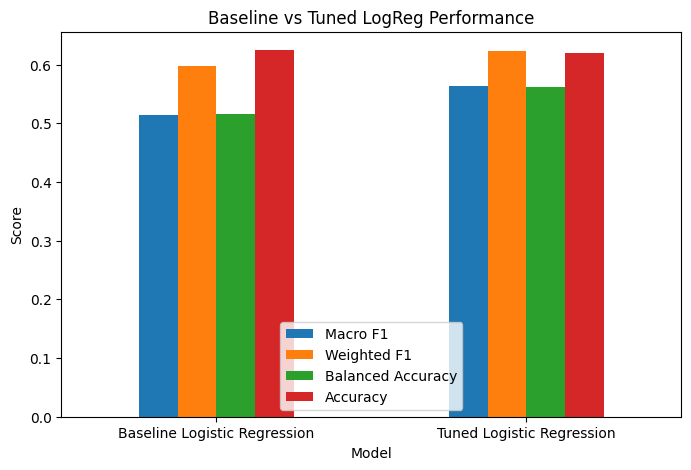

In [36]:
# Compare Baseline vs Tuned

comparison_df = pd.DataFrame({

    'Model': ['Baseline Logistic Regression','Tuned Logistic Regression'],

    'Macro F1': [baseline_LR_macro_f1,tuned_LR_macro_f1],
    'Weighted F1': [baseline_LR_weighted_f1,tuned_LR_weighted_f1],
    'Balanced Accuracy': [baseline_LR_balanced_acc,tuned_LR_balanced_acc],
    'Accuracy': [baseline_LR_accuracy,tuned_LR_accuracy]
})

print("Model Comparison")

print(comparison_df.round(4))

# Visual Comparison

comparison_df.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Baseline vs Tuned LogReg Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

Top 10 Important Features
                                              Feature  Coefficient
3                         tuition_fees_up_to_date_Yes     0.668591
6                              scholarship_holder_Yes     0.381312
2                                   age_at_enrollment     0.303506
58                               mothers_occupation_0     0.267265
23                     course_Informatics Engineering     0.220956
0                                     admission_grade     0.206776
9                                          debtor_Yes     0.204403
13                               mothers_occupation_9     0.188929
19                 application_mode_Over 23 years old     0.188394
65  application_mode_Technological specialization ...     0.178736


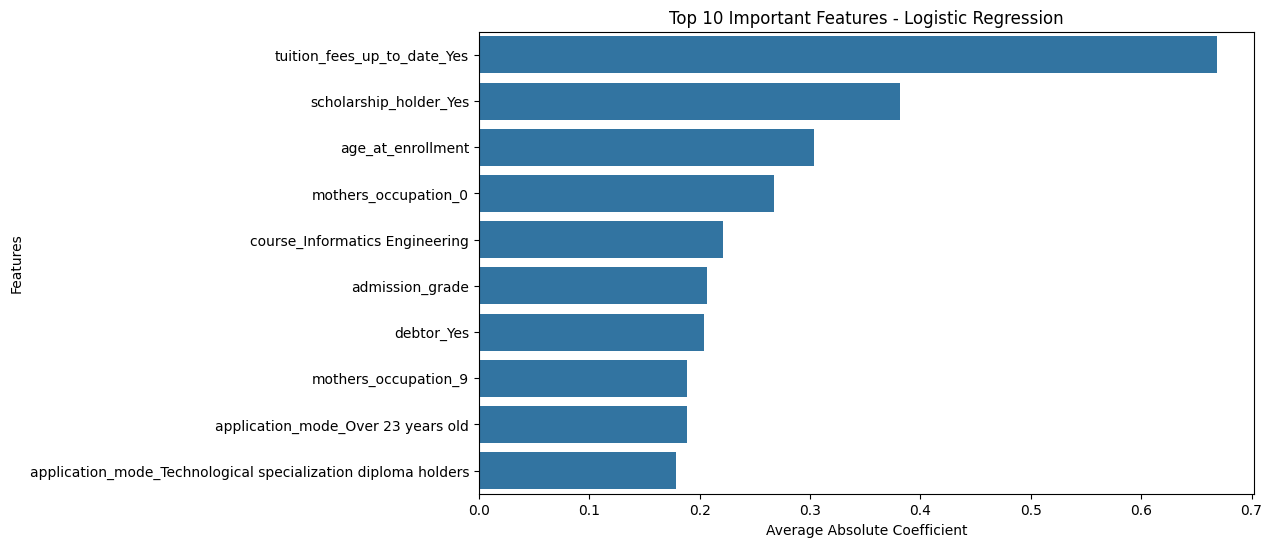

In [37]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': np.mean(
        np.abs(best_logreg.coef_),
        axis=0
    )
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

top_features = feature_importance.head(10)

print("Top 10 Important Features")

print(top_features)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title("Top 10 Important Features - Logistic Regression")
plt.xlabel("Average Absolute Coefficient")
plt.ylabel("Features")

plt.show()

**Tuned kNN vs Tuned LogReg ROC Curve**

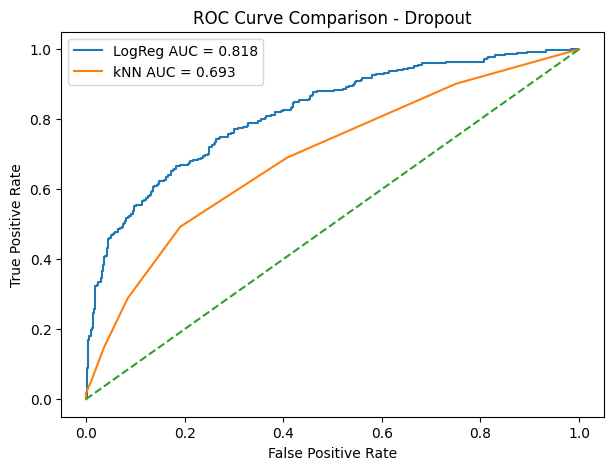

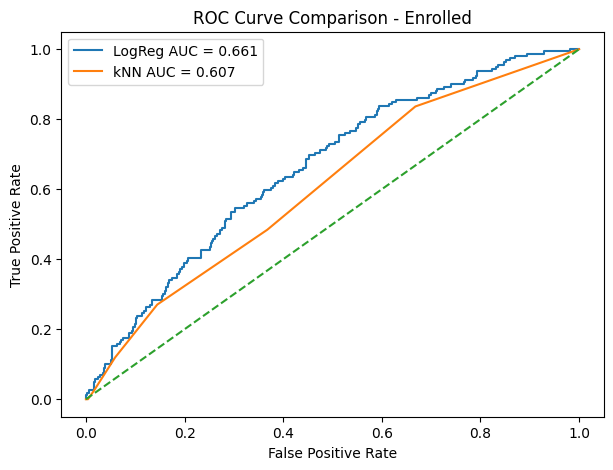

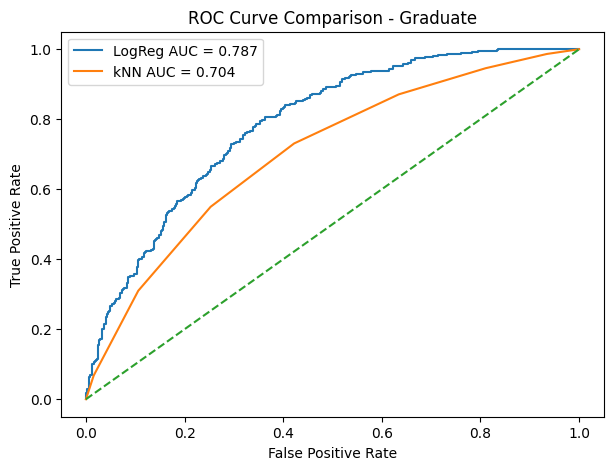

In [38]:
# ROC Curve Comparison - Tuned kNN vs Tuned Logistic Regression

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Binarize multiclass labels

classes = [0,1,2]

y_test_bin = label_binarize(y_test, classes=classes)

n_classes = y_test_bin.shape[1]

y_score_logreg = best_logreg.predict_proba(X_test_scaled)

y_score_knn = best_knn.predict_proba(X_test_scaled)

# ROC Calculation

fpr_logreg = dict()
tpr_logreg = dict()
roc_auc_logreg = dict()

fpr_knn = dict()
tpr_knn = dict()
roc_auc_knn = dict()

for i in range(n_classes):

    # Logistic Regression ROC
    fpr_logreg[i], tpr_logreg[i], _ = roc_curve(y_test_bin[:, i],y_score_logreg[:, i])

    roc_auc_logreg[i] = auc(fpr_logreg[i],tpr_logreg[i])

    # kNN ROC
    fpr_knn[i], tpr_knn[i], _ = roc_curve(y_test_bin[:, i],y_score_knn[:, i])

    roc_auc_knn[i] = auc(fpr_knn[i],tpr_knn[i])

# Plot ROC Curves
class_names = ['Dropout', 'Enrolled', 'Graduate']

for i in range(n_classes):

    plt.figure(figsize=(7,5))

    # Logistic Regression
    plt.plot(
        fpr_logreg[i],
        tpr_logreg[i],
        label=f'LogReg AUC = {roc_auc_logreg[i]:.3f}'
    )

    # kNN
    plt.plot(
        fpr_knn[i],
        tpr_knn[i],
        label=f'kNN AUC = {roc_auc_knn[i]:.3f}'
    )

    # Random line
    plt.plot([0,1], [0,1], linestyle='--')

    plt.title(f'ROC Curve Comparison - {class_names[i]}')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.legend()

    plt.show()
# Calculate macro-averaged ROC AUC for kNN
kNN_auc = roc_auc_score(y_test_bin, best_knn.predict_proba(X_test_scaled), average='macro', multi_class='ovr')

# Calculate macro-averaged ROC AUC for Logistic Regression
logreg_auc = roc_auc_score(y_test_bin, best_logreg.predict_proba(X_test_scaled), average='macro', multi_class='ovr')

**Best Model Comparison kNN vs LogReg**

In [39]:
# Final Tuned Model Comparison

comparison_models = pd.DataFrame({

    'Model': ['Tuned kNN', 'Tuned Logistic Regression'],

    'Macro F1': [
        tuned_kNN_macro_f1,
        tuned_LR_macro_f1
    ],

    'Weighted F1': [
        tuned_kNN_weighted_f1,
        tuned_LR_weighted_f1
    ],

    'Balanced Accuracy': [
        tuned_kNN_balanced_acc,
        tuned_LR_balanced_acc
    ],

    'Accuracy': [
        tuned_kNN_accuracy,
        tuned_LR_accuracy
    ]
})

print(comparison_models.round(4))

                       Model  Macro F1  Weighted F1  Balanced Accuracy  \
0                  Tuned kNN    0.4745       0.5429             0.4726   
1  Tuned Logistic Regression    0.5630       0.6225             0.5611   

   Accuracy  
0    0.5627  
1    0.6203  


In [40]:
# Individual Class F1 Scores

# kNN class-wise F1 scores
knn_class_f1 = f1_score(
    y_test,
    y_pred_best_knn,
    average=None
)

# Logistic Regression class-wise F1 scores
lr_class_f1 = f1_score(
    y_test,
    y_pred_best_logreg,
    average=None
)

# Display scores
class_labels = ['Dropout', 'Enrolled', 'Graduate']

print("kNN Class-wise F1 Scores")

for label, score in zip(class_labels, knn_class_f1):
    print(f"{label}: {round(score,4)}")

print("Logistic Regression Class-wise F1 Scores")

for label, score in zip(class_labels, lr_class_f1):
    print(f"{label}: {round(score,4)}")

kNN Class-wise F1 Scores
Dropout: 0.4725
Enrolled: 0.2618
Graduate: 0.6892
Logistic Regression Class-wise F1 Scores
Dropout: 0.6238
Enrolled: 0.3432
Graduate: 0.722


In [41]:
#saving my result in seperate file so it can be use for comparison
import os

PROJECT_DIR = "/content/drive/MyDrive/COMM074_Project"
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

my_results = pd.DataFrame([
    {
        'member': 'Vinayak',
        'model': 'kNN',
        'model_type': 'unique',
        'best_params': str(grid_search.best_params_),
        'accuracy': tuned_kNN_accuracy,
        'balanced_accuracy': tuned_kNN_balanced_acc,
        'macro_f1': tuned_kNN_macro_f1,
        'weighted_f1': tuned_kNN_weighted_f1,
        'roc_auc': kNN_auc,
        'dropout_f1': f1_score(y_test, y_pred_best_knn, average=None)[0],
        'enrolled_f1': f1_score(y_test, y_pred_best_knn, average=None)[1],
        'graduate_f1': f1_score(y_test, y_pred_best_knn, average=None)[2],
    },
    {
        'member': 'Vinayak',
        'model': 'Logistic Regression',
        'model_type': 'shared',
        'best_params': str(best_logreg.get_params()),
        'accuracy': tuned_LR_accuracy,
        'balanced_accuracy': tuned_LR_balanced_acc,
        'macro_f1': tuned_LR_macro_f1,
        'weighted_f1': tuned_LR_weighted_f1,
        'roc_auc': logreg_auc,
        'dropout_f1': f1_score(y_test, y_pred_best_logreg, average=None)[0],
        'enrolled_f1': f1_score(y_test, y_pred_best_logreg, average=None)[1],
        'graduate_f1': f1_score(y_test, y_pred_best_logreg, average=None)[2],
    },
])

results_path = os.path.join(RESULTS_DIR, 'results_vinayak.csv')
my_results.to_csv(results_path, index=False)

print(f'Saved to: {results_path}')
print(my_results[['member', 'model', 'balanced_accuracy', 'macro_f1', 'roc_auc']].to_string(index=False))

Saved to: /content/drive/MyDrive/COMM074_Project/results/results_vinayak.csv
 member               model  balanced_accuracy  macro_f1  roc_auc
Vinayak                 kNN           0.472557  0.474522 0.668075
Vinayak Logistic Regression           0.561107  0.563017 0.755252


#**References**

*   Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. IEEE Transactions on Information Theory, 13(1), 21–27.

*   Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). Applied Logistic Regression (3rd ed.). Wiley.

*   Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

* kNN: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?utm_source=chatgpt.com#sklearn.neighbors.KNeighborsClassifier.fit

*   Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html?utm_source=chatgpt.com

*   Grid search CV: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html?utm_source=chatgpt.com



